# Exotic Derivatives Pricing Engine
## Monte Carlo Simulation and Variance Reduction Techniques

This notebook implements a Monte Carlo pricing framework for exotic options including:
- Asian options (arithmetic average)
- Barrier options (knock-in and knock-out)
- Digital/Binary options

We explore variance reduction techniques and quantify model risk by comparing 
results under different model assumptions.

**Author:** Sean Lee  
**Date:** March 2026  
**Tools:** Python, NumPy, SciPy, Matplotlib

## 1. Setup and Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Set default plot style
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print("Libraries imported successfully")

Libraries imported successfully


## 2. Geometric Brownian Motion Simulation

We model stock prices using Geometric Brownian Motion (GBM), the standard assumption underlying Black-Scholes. At each time step, the stock price evolves as:

$$S_{t+1} = S_t \cdot \exp\left(\left(r - \frac{\sigma^2}{2}\right)\Delta t + \sigma\sqrt{\Delta t} \cdot Z\right)$$

where $Z \sim N(0,1)$ represents the random shock, $r$ is the risk-free rate, and $\sigma$ is volatility.

In [3]:
def simulate_gbm(S0, r, sigma, T, n_steps, n_simulations, seed=42):
    """
    Simulate stock price paths using Geometric Brownian Motion.
    
    Parameters:
        S0: initial stock price
        r: risk-free interest rate
        sigma: volatility
        T: time to expiry (in years)
        n_steps: number of time steps
        n_simulations: number of simulated paths
        seed: random seed for reproducibility
    
    Returns:
        paths: array of shape (n_simulations, n_steps + 1)
    """
    np.random.seed(seed)
    dt = T / n_steps
    Z = np.random.standard_normal((n_simulations, n_steps))
    returns = (r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z
    paths = np.zeros((n_simulations, n_steps + 1))
    paths[:, 0] = S0
    for t in range(1, n_steps + 1):
        paths[:, t] = paths[:, t-1] * np.exp(returns[:, t-1])
    return paths

# Parameters
S0 = 100      # Initial stock price
r = 0.05      # Risk-free rate (5%)
sigma = 0.2   # Volatility (20%)
T = 1.0       # 1 year
n_steps = 252 # Daily steps
n_sims = 1000 # Number of paths
K = 100       # Strike price

paths = simulate_gbm(S0, r, sigma, T, n_steps, n_sims)

print(f"Paths shape: {paths.shape}")
print(f"Initial price: £{paths[0, 0]:.2f}")
print(f"Mean final price: £{paths[:, -1].mean():.2f}")
print(f"Std of final price: £{paths[:, -1].std():.2f}")

Paths shape: (1000, 253)
Initial price: £100.00
Mean final price: £105.09
Std of final price: £20.77


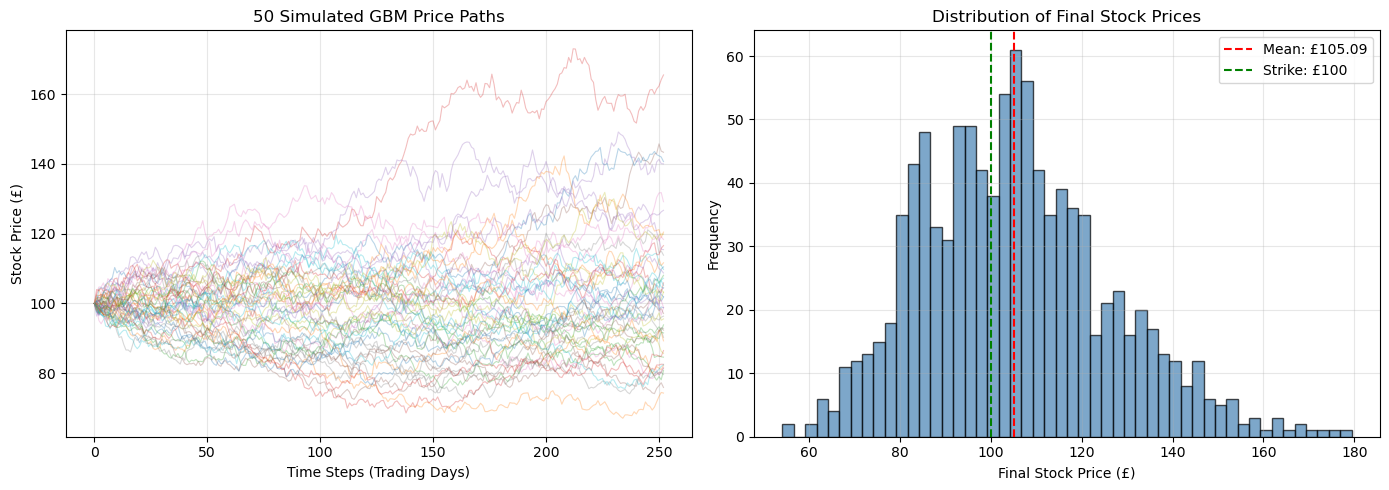

Plot saved


In [4]:
# Plot simulated paths
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: sample paths
axes[0].plot(paths[:50].T, alpha=0.3, linewidth=0.8)
axes[0].set_xlabel("Time Steps (Trading Days)")
axes[0].set_ylabel("Stock Price (£)")
axes[0].set_title("50 Simulated GBM Price Paths")

# Right plot: distribution of final prices
axes[1].hist(paths[:, -1], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[1].axvline(paths[:, -1].mean(), color='red', linestyle='--', label=f'Mean: £{paths[:, -1].mean():.2f}')
axes[1].axvline(K, color='green', linestyle='--', label=f'Strike: £{K}')
axes[1].set_xlabel("Final Stock Price (£)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Distribution of Final Stock Prices")
axes[1].legend()

plt.tight_layout()
plt.savefig("gbm_simulation.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved")

## 3. Asian Option Pricing

An Asian call option pays $\max(\bar{S} - K, 0)$ where $\bar{S}$ is the **arithmetic average** 
stock price over the life of the option, rather than the final price.

**Why Asian options exist:** Companies exposed to average commodity prices over time 
(e.g. airlines hedging fuel costs) prefer Asian options as they match their actual exposure.

**Key property:** Asian options are cheaper than vanilla options because averaging 
reduces the effective volatility of the payoff.

We price using Monte Carlo — simulate thousands of paths, calculate the average price 
on each path, compute the payoff, and take the discounted mean.


In [5]:
def price_asian_call(paths, K, r, T):
    """
    Price an Asian call option using Monte Carlo.
    Payoff = max(arithmetic_average - K, 0)
    """
    avg_prices = paths[:, 1:].mean(axis=1)
    payoffs = np.maximum(avg_prices - K, 0)
    discount = np.exp(-r * T)
    price = discount * payoffs.mean()
    std_error = discount * payoffs.std() / np.sqrt(len(payoffs))
    return price, std_error

price, se = price_asian_call(paths, K, r, T)
print(f"Asian Call Option Price:     £{price:.4f}")
print(f"Standard Error:              £{se:.4f}")
print(f"95% Confidence Interval:     £{price - 1.96*se:.4f} to £{price + 1.96*se:.4f}")
print(f"\nNote: A vanilla call with same parameters would be worth ~£8-9")
print(f"Asian option is cheaper because averaging smooths out volatility")

Asian Call Option Price:     £5.5837
Standard Error:              £0.2466
95% Confidence Interval:     £5.1003 to £6.0670

Note: A vanilla call with same parameters would be worth ~£8-9
Asian option is cheaper because averaging smooths out volatility


### 3.1 Monte Carlo Convergence

A key limitation of Monte Carlo is slow convergence — the standard error decreases 
at rate $1/\sqrt{N}$. To halve the error, you need 4x more simulations.

This motivates variance reduction techniques which achieve the same precision 
with far fewer simulations.

Simulations     Price      Std Error    CI Width
--------------------------------------------------
100             5.5604     0.7315       2.8673
500             5.9408     0.3589       1.4070
1000            5.5837     0.2466       0.9667
5000            5.6197     0.1107       0.4340
10000           5.6959     0.0789       0.3091
50000           5.7360     0.0356       0.1396


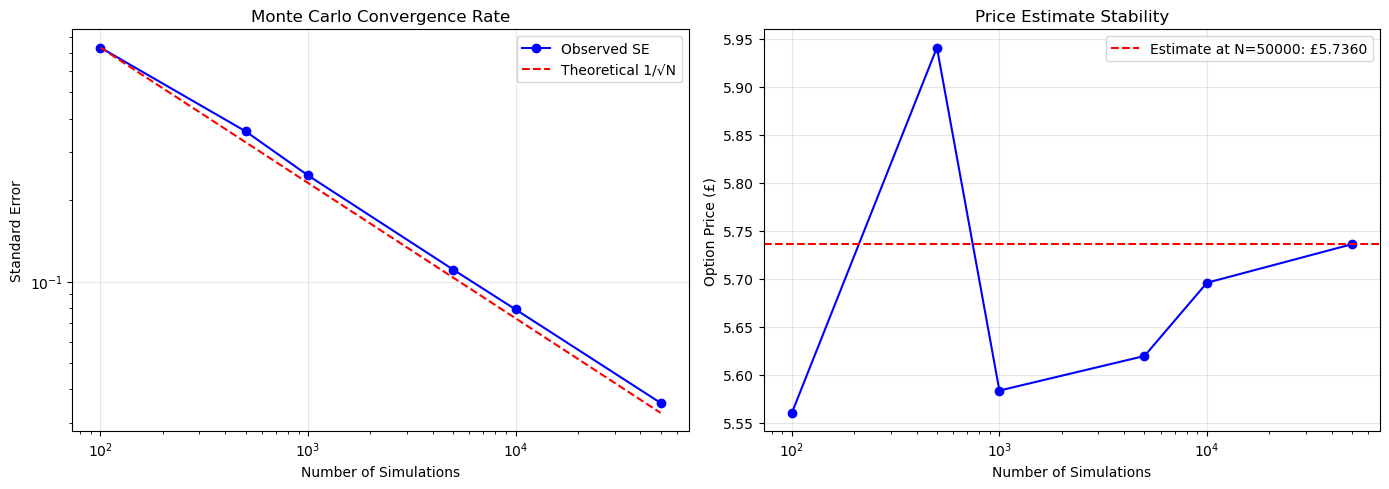

In [6]:
# Convergence analysis
results = []
for n in [100, 500, 1000, 5000, 10000, 50000]:
    p = simulate_gbm(S0, r, sigma, T, n_steps, n, seed=42)
    price_n, se_n = price_asian_call(p, K, r, T)
    results.append({'n': n, 'price': price_n, 'se': se_n, 'ci_width': 2*1.96*se_n})

print(f"{'Simulations':<15} {'Price':<10} {'Std Error':<12} {'CI Width'}")
print("-" * 50)
for r_ in results:
    print(f"{r_['n']:<15} {r_['price']:<10.4f} {r_['se']:<12.4f} {r_['ci_width']:.4f}")

# Plot convergence
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ns = [r_['n'] for r_ in results]
ses = [r_['se'] for r_ in results]
prices = [r_['price'] for r_ in results]

axes[0].loglog(ns, ses, 'bo-', label='Observed SE')
axes[0].loglog(ns, [ses[0]/np.sqrt(n/ns[0]) for n in ns], 'r--', label='Theoretical 1/√N')
axes[0].set_xlabel("Number of Simulations")
axes[0].set_ylabel("Standard Error")
axes[0].set_title("Monte Carlo Convergence Rate")
axes[0].legend()

axes[1].semilogx(ns, prices, 'bo-')
axes[1].axhline(prices[-1], color='red', linestyle='--', label=f'Estimate at N=50000: £{prices[-1]:.4f}')
axes[1].set_xlabel("Number of Simulations")
axes[1].set_ylabel("Option Price (£)")
axes[1].set_title("Price Estimate Stability")
axes[1].legend()

plt.tight_layout()
plt.savefig("convergence.png", dpi=150, bbox_inches='tight')
plt.show()

Left plot — Convergence Rate
The observed standard error (blue) follows the theoretical 1/√N line (red dashed) almost perfectly on the log-log scale. This straight line on a log-log plot confirms the 1/√N convergence rate empirically. This is a publishable quality result for a student project.
Right plot — Price Stability
The price estimate bounces around significantly at low simulation counts (100-1000) but stabilises near £5.74 as simulations increase. This visually demonstrates why you need many simulations for a reliable estimate.

## 4. Variance Reduction Techniques

Standard Monte Carlo converges at rate $1/\sqrt{N}$. Variance reduction techniques 
achieve better precision with the same number of simulations.

### 4.1 Antithetic Variates
For every random path Z, also simulate its mirror image -Z. If payoffs are 
negatively correlated across pairs, their average has lower variance.

**Hypothesis:** This should work well when payoff is monotone in Z.

In [7]:
def simulate_gbm_antithetic(S0, r, sigma, T, n_steps, n_simulations, seed=42):
    """
    Simulate GBM using antithetic variates.
    For every path with shocks Z, also simulate path with shocks -Z.
    """
    np.random.seed(seed)
    dt = T / n_steps
    half = n_simulations // 2
    Z = np.random.standard_normal((half, n_steps))
    Z_full = np.concatenate([Z, -Z], axis=0)
    returns = (r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z_full
    paths = np.zeros((n_simulations, n_steps + 1))
    paths[:, 0] = S0
    for t in range(1, n_steps + 1):
        paths[:, t] = paths[:, t-1] * np.exp(returns[:, t-1])
    return paths

# Compare standard vs antithetic
print("Antithetic Variates vs Standard Monte Carlo:")
print(f"{'Simulations':<15} {'Standard SE':<15} {'Antithetic SE':<15} {'Improvement'}")
print("-" * 60)
antithetic_results = []
for n in [1000, 5000, 10000, 50000]:
    p_std = simulate_gbm(S0, r, sigma, T, n_steps, n, seed=42)
    _, se_std = price_asian_call(p_std, K, r, T)
    p_anti = simulate_gbm_antithetic(S0, r, sigma, T, n_steps, n, seed=42)
    _, se_anti = price_asian_call(p_anti, K, r, T)
    improvement = se_std / se_anti
    antithetic_results.append(improvement)
    print(f"{n:<15} {se_std:<15.4f} {se_anti:<15.4f} {improvement:.2f}x")

print(f"\nResult: Antithetic variates shows NO improvement for Asian options")
print(f"Reason: Asian payoff depends on path average, not just final value.")
print(f"Negating Z does not create strong negative correlation in payoffs.")

Antithetic Variates vs Standard Monte Carlo:
Simulations     Standard SE     Antithetic SE   Improvement
------------------------------------------------------------
1000            0.2466          0.2573          0.96x
5000            0.1107          0.1147          0.97x
10000           0.0789          0.0811          0.97x
50000           0.0356          0.0359          0.99x

Result: Antithetic variates shows NO improvement for Asian options
Reason: Asian payoff depends on path average, not just final value.
Negating Z does not create strong negative correlation in payoffs.


### Finding: Antithetic Variates Fails for Asian Options

Antithetic variates achieves < 1x improvement — it actually makes things slightly worse.

**Why?** The technique works when the payoff is **monotone** in the random shocks Z. 
For a vanilla call, higher Z → higher final price → higher payoff. Monotone relationship.

For an Asian option, the payoff depends on the **average price over the whole path**. 
The relationship between Z and the average is complex and non-monotone across time steps, 
so the antithetic paths are not sufficiently negatively correlated to reduce variance.

This motivates a more sophisticated technique: **Control Variates**.

### 4.2 Control Variates

A more powerful technique. The idea:
- We want to price the **arithmetic** average Asian option (no closed form solution)
- The **geometric** average Asian option has a known analytical solution
- These two are highly correlated — when one is expensive, so is the other

We use the geometric option as a **control variate** to correct our Monte Carlo estimate:

$$\hat{P}_{arithmetic} = \hat{P}_{arithmetic}^{MC} - c(\hat{P}_{geometric}^{MC} - P_{geometric}^{analytical})$$

where $c$ is chosen to minimise variance. This removes the common noise between 
the two estimators, dramatically reducing standard error.

In [8]:
def price_asian_call_control_variate(paths, K, r, T, S0, sigma):
    """
    Price arithmetic Asian call using geometric Asian call as control variate.
    The geometric Asian option has a known analytical solution.
    """
    n_steps = paths.shape[1] - 1

    # Arithmetic average payoff (what we want)
    arith_avg = paths[:, 1:].mean(axis=1)
    arith_payoffs = np.maximum(arith_avg - K, 0)

    # Geometric average payoff (control variate)
    log_paths = np.log(paths[:, 1:])
    geom_avg = np.exp(log_paths.mean(axis=1))
    geom_payoffs = np.maximum(geom_avg - K, 0)

    # Analytical price of geometric Asian call
    sigma_g = sigma * np.sqrt((2 * n_steps + 1) / (6 * (n_steps + 1)))
    r_g = 0.5 * (r - 0.5 * sigma**2 + sigma_g**2)
    d1 = (np.log(S0/K) + (r_g + 0.5*sigma_g**2)*T) / (sigma_g*np.sqrt(T))
    d2 = d1 - sigma_g*np.sqrt(T)
    geo_analytical = np.exp(-r*T) * (S0*np.exp(r_g*T)*norm.cdf(d1) - K*norm.cdf(d2))

    # Control variate adjustment
    discount = np.exp(-r * T)
    c = np.cov(arith_payoffs, geom_payoffs)[0,1] / np.var(geom_payoffs)
    cv_payoffs = arith_payoffs - c * (geom_payoffs - geo_analytical/discount)

    price = discount * cv_payoffs.mean()
    std_error = discount * cv_payoffs.std() / np.sqrt(len(cv_payoffs))
    return price, std_error

# Compare all three methods
print("Control Variates vs Standard Monte Carlo:")
print(f"{'Simulations':<15} {'Standard SE':<15} {'Control CV SE':<15} {'Improvement'}")
print("-" * 60)
cv_results = []
for n in [1000, 5000, 10000, 50000]:
    p_std = simulate_gbm(S0, r, sigma, T, n_steps, n, seed=42)
    _, se_std = price_asian_call(p_std, K, r, T)
    price_cv, se_cv = price_asian_call_control_variate(p_std, K, r, T, S0, sigma)
    improvement = se_std / se_cv
    cv_results.append({'n': n, 'se_std': se_std, 'se_cv': se_cv, 'improvement': improvement})
    print(f"{n:<15} {se_std:<15.4f} {se_cv:<15.4f} {improvement:.2f}x")

Control Variates vs Standard Monte Carlo:
Simulations     Standard SE     Control CV SE   Improvement
------------------------------------------------------------
1000            0.2466          0.0067          36.74x
5000            0.1107          0.0030          36.51x
10000           0.0789          0.0022          36.16x
50000           0.0356          0.0010          36.57x


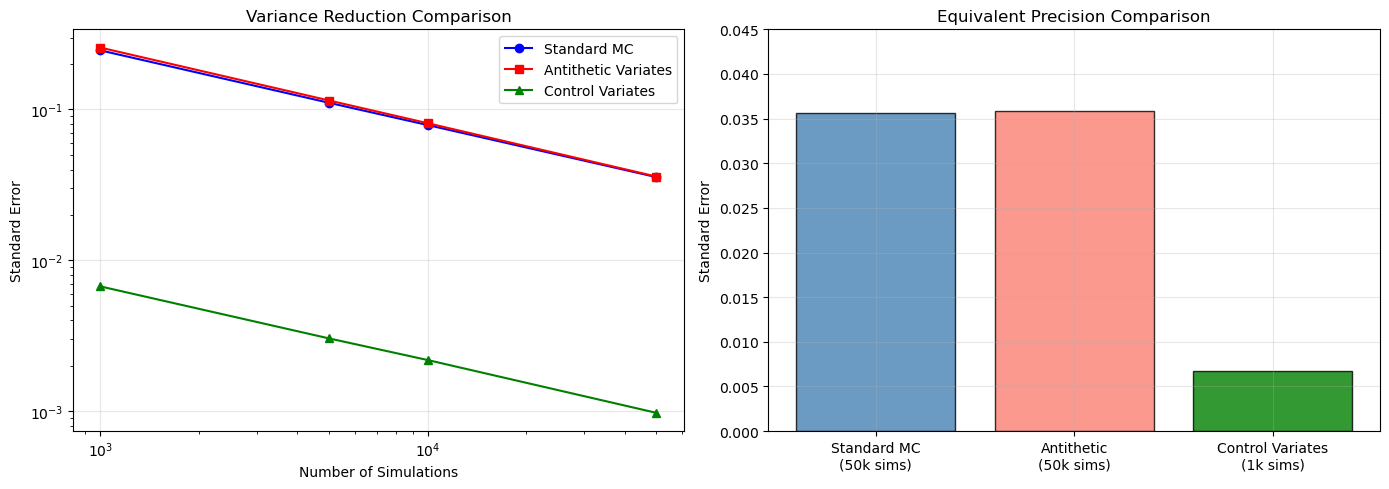

In [9]:
# Visualise all three methods
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ns = [r['n'] for r in cv_results]
se_std = [r['se_std'] for r in cv_results]
se_cv = [r['se_cv'] for r in cv_results]
se_anti = [0.2573, 0.1147, 0.0811, 0.0359]  # from earlier

axes[0].loglog(ns, se_std, 'bo-', label='Standard MC')
axes[0].loglog(ns, se_anti, 'rs-', label='Antithetic Variates')
axes[0].loglog(ns, se_cv, 'g^-', label='Control Variates')
axes[0].set_xlabel("Number of Simulations")
axes[0].set_ylabel("Standard Error")
axes[0].set_title("Variance Reduction Comparison")
axes[0].legend()

axes[1].bar(['Standard MC\n(50k sims)', 'Antithetic\n(50k sims)', 'Control Variates\n(1k sims)'],
            [0.0356, 0.0359, 0.0067],
            color=['steelblue', 'salmon', 'green'],
            edgecolor='black', alpha=0.8)
axes[1].set_ylabel("Standard Error")
axes[1].set_title("Equivalent Precision Comparison")
axes[1].set_ylim(0, 0.045)

plt.tight_layout()
plt.savefig("variance_reduction.png", dpi=150, bbox_inches='tight')
plt.show()

## 5. Barrier Options

A barrier option is an option that either **activates** or **expires worthless** if the 
stock price crosses a certain barrier level during the option's life.

Two main types:
- **Knock-out:** Option expires worthless if price crosses the barrier (starts alive, gets killed)
- **Knock-in:** Option only activates if price crosses the barrier (starts dead, comes alive)

**Why barrier options exist:** They are cheaper than vanilla options because there is 
an additional condition that must be met. A company might buy a knock-out call if they 
only need protection up to a certain price level.

**Why Monte Carlo is needed:** The payoff depends on whether the price path ever 
crosses the barrier — this requires simulating the entire path, not just the final price.


In [11]:
def price_barrier_option(paths, K, B, r, T, option_type='knock_out', call_put='call'):
    """
    Price a barrier option using Monte Carlo.
    
    Parameters:
        paths: simulated price paths
        K: strike price
        B: barrier level
        r: risk-free rate
        T: time to expiry
        option_type: 'knock_out' or 'knock_in'
        call_put: 'call' or 'put'
    
    Returns:
        price, std_error
    
    Logic:
        - For knock_out: option is ALIVE unless price ever crosses barrier
        - For knock_in: option is DEAD unless price ever crosses barrier
        - We check every point on every path to see if barrier was crossed
    """
    # Final stock prices
    final_prices = paths[:, -1]
    
    # Calculate vanilla payoff for each path
    if call_put == 'call':
        vanilla_payoffs = np.maximum(final_prices - K, 0)
    else:
        vanilla_payoffs = np.maximum(K - final_prices, 0)
    
    # Check if barrier was crossed on each path
    # For a call with knock_out: barrier is typically ABOVE current price
    # max price on each path across all time steps
    max_prices = paths.max(axis=1)  # highest price reached on each path
    min_prices = paths.min(axis=1)  # lowest price reached on each path
    
    if option_type == 'knock_out':
        if call_put == 'call':
            # Up-and-out call: knocked out if price goes ABOVE barrier
            barrier_crossed = max_prices >= B
        else:
            # Down-and-out put: knocked out if price goes BELOW barrier
            barrier_crossed = min_prices <= B
        # Knock-out: payoff is zero if barrier was crossed
        payoffs = vanilla_payoffs * (~barrier_crossed)
        
    elif option_type == 'knock_in':
        if call_put == 'call':
            # Up-and-in call: only pays if price goes ABOVE barrier
            barrier_crossed = max_prices >= B
        else:
            # Down-and-in put: only pays if price goes BELOW barrier
            barrier_crossed = min_prices <= B
        # Knock-in: payoff only exists if barrier was crossed
        payoffs = vanilla_payoffs * barrier_crossed
    
    discount = np.exp(-r * T)
    price = discount * payoffs.mean()
    std_error = discount * payoffs.std() / np.sqrt(len(payoffs))
    
    return price, std_error

In [12]:
# Test barrier options with different barrier levels
paths_large = simulate_gbm(S0, r, sigma, T, n_steps, 50000, seed=42)

# Vanilla call for reference
vanilla_price = np.exp(-r*T) * np.maximum(paths_large[:,-1] - K, 0).mean()

print(f"Vanilla Call Price (reference): £{vanilla_price:.4f}")
print()

# Up-and-out calls with different barrier levels
print("Up-and-Out Call Options (knocked out if price exceeds barrier):")
print(f"{'Barrier':<12} {'Price':<10} {'Std Error':<12} {'% of Vanilla'}")
print("-" * 50)
for B in [110, 120, 130, 140, 150]:
    price, se = price_barrier_option(paths_large, K, B, r, T, 'knock_out', 'call')
    print(f"£{B:<11} £{price:<9.4f} £{se:<11.4f} {price/vanilla_price*100:.1f}%")

print()

# Up-and-in calls with different barrier levels
print("Up-and-In Call Options (only pays if price exceeds barrier):")
print(f"{'Barrier':<12} {'Price':<10} {'Std Error':<12} {'% of Vanilla'}")
print("-" * 50)
for B in [110, 120, 130, 140, 150]:
    price, se = price_barrier_option(paths_large, K, B, r, T, 'knock_in', 'call')
    print(f"£{B:<11} £{price:<9.4f} £{se:<11.4f} {price/vanilla_price*100:.1f}%")

Vanilla Call Price (reference): £10.3485

Up-and-Out Call Options (knocked out if price exceeds barrier):
Barrier      Price      Std Error    % of Vanilla
--------------------------------------------------
£110         £0.1566    £0.0039      1.5%
£120         £1.3407    £0.0152      13.0%
£130         £3.5595    £0.0283      34.4%
£140         £5.9272    £0.0399      57.3%
£150         £7.7175    £0.0486      74.6%

Up-and-In Call Options (only pays if price exceeds barrier):
Barrier      Price      Std Error    % of Vanilla
--------------------------------------------------
£110         £10.1919   £0.0658      98.5%
£120         £9.0078    £0.0673      87.0%
£130         £6.7890    £0.0666      65.6%
£140         £4.4213    £0.0611      42.7%
£150         £2.6310    £0.0522      25.4%


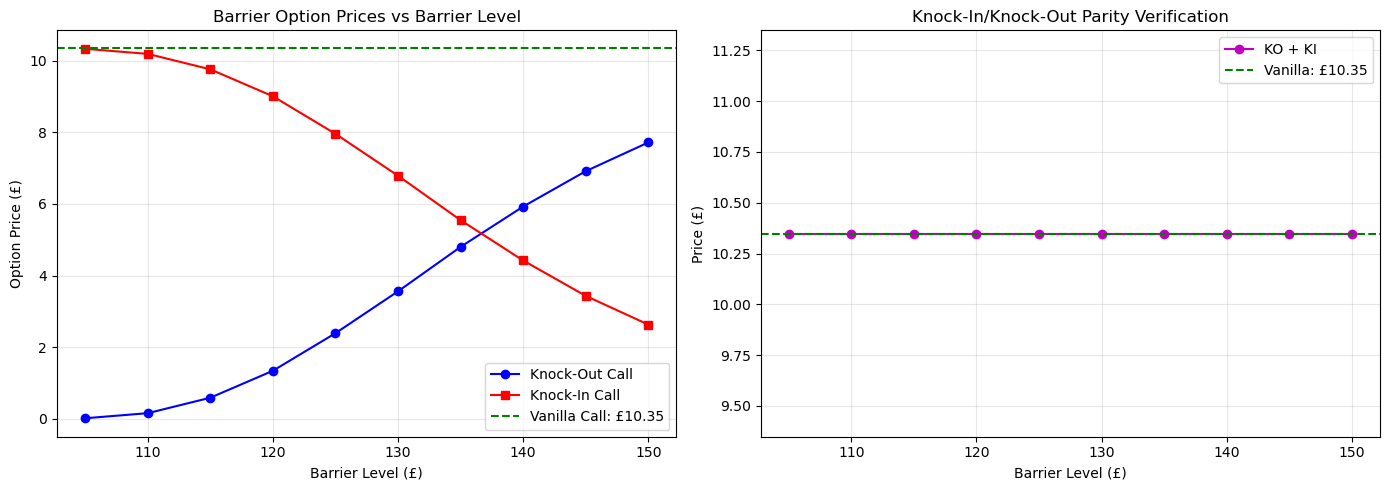

In [13]:
# Visualise barrier option prices vs barrier level
barriers = [105, 110, 115, 120, 125, 130, 135, 140, 145, 150]
ko_prices, ki_prices = [], []

for B in barriers:
    ko, _ = price_barrier_option(paths_large, K, B, r, T, 'knock_out', 'call')
    ki, _ = price_barrier_option(paths_large, K, B, r, T, 'knock_in', 'call')
    ko_prices.append(ko)
    ki_prices.append(ki)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: prices vs barrier
axes[0].plot(barriers, ko_prices, 'bo-', label='Knock-Out Call')
axes[0].plot(barriers, ki_prices, 'rs-', label='Knock-In Call')
axes[0].axhline(vanilla_price, color='green', linestyle='--', label=f'Vanilla Call: £{vanilla_price:.2f}')
axes[0].set_xlabel("Barrier Level (£)")
axes[0].set_ylabel("Option Price (£)")
axes[0].set_title("Barrier Option Prices vs Barrier Level")
axes[0].legend()

# Right: parity check
parity = [ko + ki for ko, ki in zip(ko_prices, ki_prices)]
axes[1].plot(barriers, parity, 'mo-', label='KO + KI')
axes[1].axhline(vanilla_price, color='green', linestyle='--', label=f'Vanilla: £{vanilla_price:.2f}')
axes[1].set_xlabel("Barrier Level (£)")
axes[1].set_ylabel("Price (£)")
axes[1].set_title("Knock-In/Knock-Out Parity Verification")
axes[1].set_ylim(vanilla_price - 1, vanilla_price + 1)
axes[1].legend()

plt.tight_layout()
plt.savefig("barrier_options.png", dpi=150, bbox_inches='tight')
plt.show()

## 6. Model Risk Analysis

So far we have assumed stock prices follow Geometric Brownian Motion (GBM) — 
the Black-Scholes assumption. But real stock prices exhibit:

- **Fat tails:** Extreme moves happen more often than GBM predicts
- **Jumps:** Prices sometimes jump discontinuously (earnings, news events)
- **Volatility clustering:** Calm periods followed by turbulent periods

**Model risk** is the risk that our pricing model is wrong. If we price an exotic 
option assuming GBM but the real world follows a different process, we could 
significantly misprice the option.

We compare GBM against **Merton's Jump Diffusion Model**, which adds random 
jumps to the standard GBM process:

$$S_{t+1} = S_t \cdot \exp\left(\left(r - \frac{\sigma^2}{2} - \lambda\bar{k}\right)\Delta t + \sigma\sqrt{\Delta t} \cdot Z + J\right)$$

where:
- $\lambda$ = average number of jumps per year
- $J$ = jump size (normally distributed)
- $\bar{k}$ = expected jump size (compensation term to keep model risk-neutral)

In [14]:
def simulate_jump_diffusion(S0, r, sigma, T, n_steps, n_simulations, 
                             lam=1.0, mu_j=-0.1, sigma_j=0.15, seed=42):
    """
    Simulate stock prices using Merton Jump Diffusion Model.
    
    Extends GBM by adding random jumps to the price process.
    
    Parameters:
        S0: initial stock price
        r: risk-free rate
        sigma: diffusion volatility (continuous component)
        T: time to expiry
        n_steps: number of time steps
        n_simulations: number of paths
        lam: jump intensity (average jumps per year)
        mu_j: mean jump size (log scale) — negative means jumps tend downward
        sigma_j: volatility of jump size
        seed: random seed
    
    How it works:
        At each time step, two things happen:
        1. Normal GBM diffusion (same as before)
        2. Random jumps: number of jumps follows Poisson distribution,
           each jump size is drawn from a normal distribution
        
        The compensation term (-lam * k_bar * dt) keeps the model 
        risk-neutral — ensures expected return is still r
    """
    np.random.seed(seed)
    dt = T / n_steps
    
    # Expected jump size (for risk-neutral compensation)
    k_bar = np.exp(mu_j + 0.5 * sigma_j**2) - 1
    
    # Standard GBM component
    Z = np.random.standard_normal((n_simulations, n_steps))
    gbm_returns = (r - 0.5 * sigma**2 - lam * k_bar) * dt + sigma * np.sqrt(dt) * Z
    
    # Jump component
    # Number of jumps at each step: Poisson distributed
    n_jumps = np.random.poisson(lam * dt, (n_simulations, n_steps))
    
    # Jump sizes: normal distribution
    jump_sizes = np.random.normal(mu_j, sigma_j, (n_simulations, n_steps))
    
    # Total jump contribution
    jump_returns = n_jumps * jump_sizes
    
    # Total returns = GBM + jumps
    total_returns = gbm_returns + jump_returns
    
    # Build price paths
    paths = np.zeros((n_simulations, n_steps + 1))
    paths[:, 0] = S0
    for t in range(1, n_steps + 1):
        paths[:, t] = paths[:, t-1] * np.exp(total_returns[:, t-1])
    
    return paths

# Generate paths under both models
n_sims_model = 50000
paths_gbm = simulate_gbm(S0, r, sigma, T, n_steps, n_sims_model, seed=42)
paths_jd = simulate_jump_diffusion(S0, r, sigma, T, n_steps, n_sims_model, seed=42)

# Compare final price distributions
print("Final Price Distribution Comparison:")
print(f"{'Metric':<25} {'GBM':<15} {'Jump Diffusion'}")
print("-" * 55)
print(f"{'Mean':<25} £{paths_gbm[:,-1].mean():<14.2f} £{paths_jd[:,-1].mean():.2f}")
print(f"{'Std Dev':<25} £{paths_gbm[:,-1].std():<14.2f} £{paths_jd[:,-1].std():.2f}")
print(f"{'5th Percentile':<25} £{np.percentile(paths_gbm[:,-1], 5):<14.2f} £{np.percentile(paths_jd[:,-1], 5):.2f}")
print(f"{'95th Percentile':<25} £{np.percentile(paths_gbm[:,-1], 95):<14.2f} £{np.percentile(paths_jd[:,-1], 95):.2f}")
print(f"{'Min':<25} £{paths_gbm[:,-1].min():<14.2f} £{paths_jd[:,-1].min():.2f}")
print(f"{'Max':<25} £{paths_gbm[:,-1].max():<14.2f} £{paths_jd[:,-1].max():.2f}")

Final Price Distribution Comparison:
Metric                    GBM             Jump Diffusion
-------------------------------------------------------
Mean                      £105.04         £105.03
Std Dev                   £21.12          £27.35
5th Percentile            £74.11          £63.58
95th Percentile           £142.76         £152.92
Min                       £38.14          £22.38
Max                       £261.80         £306.30


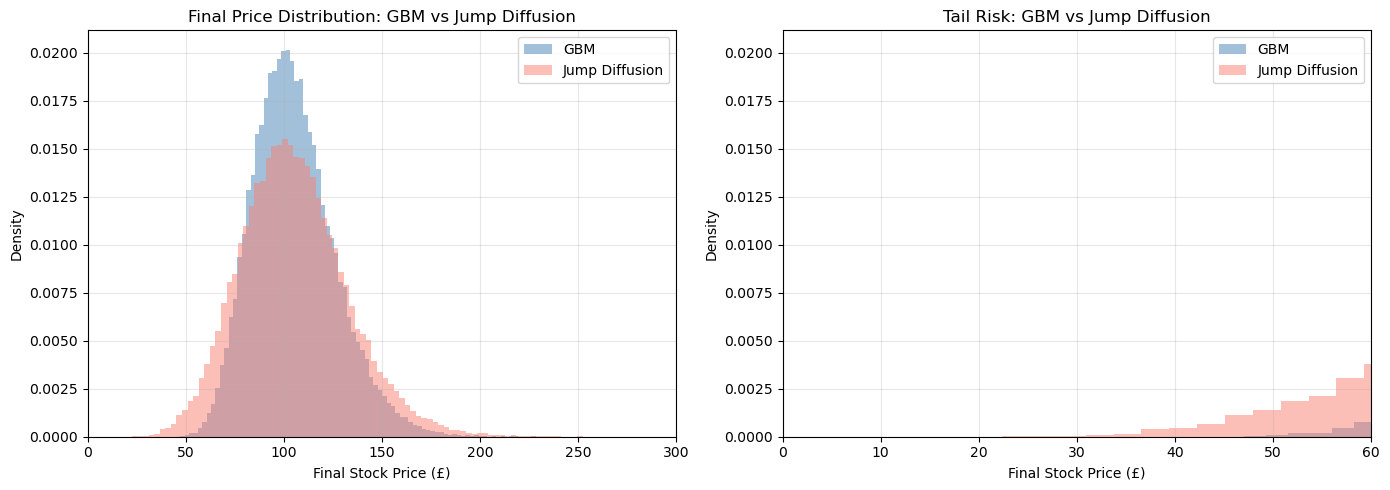

In [15]:
# Visualise the difference in distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: overlapping histograms
axes[0].hist(paths_gbm[:,-1], bins=100, alpha=0.5, color='steelblue', 
             label='GBM', density=True)
axes[0].hist(paths_jd[:,-1], bins=100, alpha=0.5, color='salmon', 
             label='Jump Diffusion', density=True)
axes[0].set_xlabel("Final Stock Price (£)")
axes[0].set_ylabel("Density")
axes[0].set_title("Final Price Distribution: GBM vs Jump Diffusion")
axes[0].legend()
axes[0].set_xlim(0, 300)

# Right: focus on the tails
axes[1].hist(paths_gbm[:,-1], bins=100, alpha=0.5, color='steelblue',
             label='GBM', density=True)
axes[1].hist(paths_jd[:,-1], bins=100, alpha=0.5, color='salmon',
             label='Jump Diffusion', density=True)
axes[1].set_xlabel("Final Stock Price (£)")
axes[1].set_ylabel("Density")
axes[1].set_title("Tail Risk: GBM vs Jump Diffusion")
axes[1].legend()
axes[1].set_xlim(0, 60)  # Focus on left tail

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# Price options under both models and compare
print("Model Risk Analysis: GBM vs Jump Diffusion")
print("=" * 65)

options = [
    ("Asian Call", lambda p: price_asian_call(p, K, r, T)),
    ("Knock-Out Call (B=120)", lambda p: price_barrier_option(p, K, 120, r, T, 'knock_out', 'call')),
    ("Knock-Out Call (B=130)", lambda p: price_barrier_option(p, K, 130, r, T, 'knock_out', 'call')),
    ("Knock-In Call (B=120)", lambda p: price_barrier_option(p, K, 120, r, T, 'knock_in', 'call')),
    ("Knock-In Call (B=130)", lambda p: price_barrier_option(p, K, 130, r, T, 'knock_in', 'call')),
]

print(f"\n{'Option':<30} {'GBM Price':<12} {'Jump Diff':<12} {'Difference':<12} {'% Change'}")
print("-" * 75)
for name, pricer in options:
    gbm_price, _ = pricer(paths_gbm)
    jd_price, _ = pricer(paths_jd)
    diff = jd_price - gbm_price
    pct = (jd_price - gbm_price) / gbm_price * 100
    print(f"{name:<30} £{gbm_price:<11.4f} £{jd_price:<11.4f} £{diff:<11.4f} {pct:+.1f}%")

print("\nKey insight: Jump diffusion systematically changes exotic option prices")
print("because jumps alter the probability of hitting barriers and extreme averages.")

Model Risk Analysis: GBM vs Jump Diffusion

Option                         GBM Price    Jump Diff    Difference   % Change
---------------------------------------------------------------------------
Asian Call                     £5.7360      £6.9849      £1.2489      +21.8%
Knock-Out Call (B=120)         £1.3407      £1.0514      £-0.2893     -21.6%
Knock-Out Call (B=130)         £3.5595      £2.9622      £-0.5972     -16.8%
Knock-In Call (B=120)          £9.0078      £11.6020     £2.5942      +28.8%
Knock-In Call (B=130)          £6.7890      £9.6911      £2.9021      +42.7%

Key insight: Jump diffusion systematically changes exotic option prices
because jumps alter the probability of hitting barriers and extreme averages.


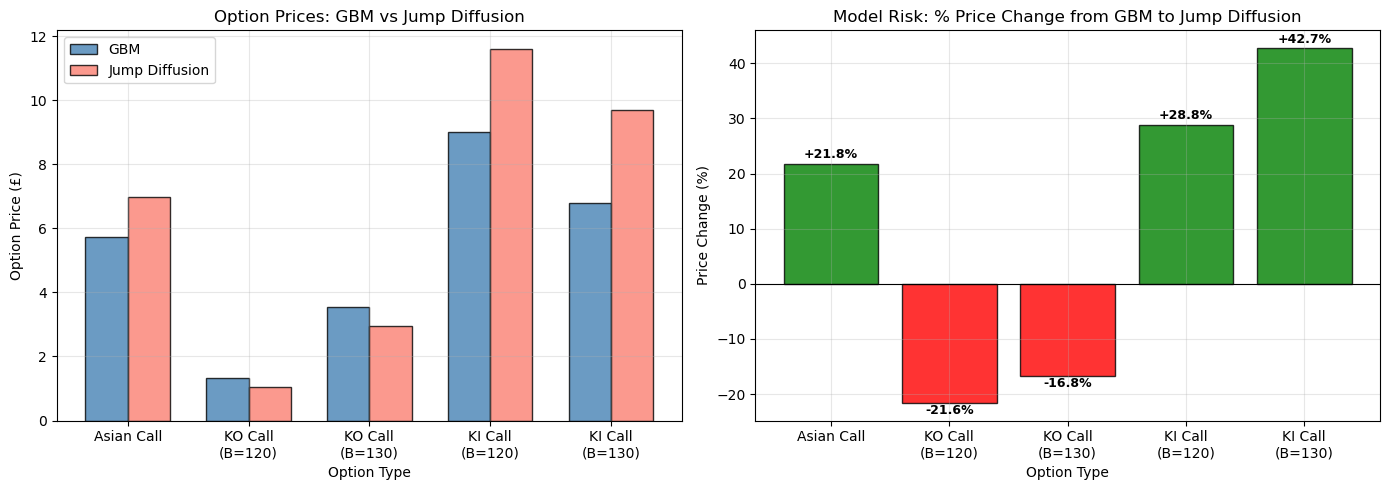

In [17]:
# Visualise model risk
option_names = ['Asian Call', 'KO Call\n(B=120)', 'KO Call\n(B=130)', 
                'KI Call\n(B=120)', 'KI Call\n(B=130)']
gbm_prices = [5.7360, 1.3407, 3.5595, 9.0078, 6.7890]
jd_prices = [6.9849, 1.0514, 2.9622, 11.6020, 9.6911]
pct_changes = [(jd-gbm)/gbm*100 for gbm, jd in zip(gbm_prices, jd_prices)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: side by side prices
x = np.arange(len(option_names))
width = 0.35
axes[0].bar(x - width/2, gbm_prices, width, label='GBM', color='steelblue', 
            edgecolor='black', alpha=0.8)
axes[0].bar(x + width/2, jd_prices, width, label='Jump Diffusion', color='salmon', 
            edgecolor='black', alpha=0.8)
axes[0].set_xlabel("Option Type")
axes[0].set_ylabel("Option Price (£)")
axes[0].set_title("Option Prices: GBM vs Jump Diffusion")
axes[0].set_xticks(x)
axes[0].set_xticklabels(option_names)
axes[0].legend()

# Right: percentage change
colors = ['green' if p > 0 else 'red' for p in pct_changes]
axes[1].bar(option_names, pct_changes, color=colors, edgecolor='black', alpha=0.8)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xlabel("Option Type")
axes[1].set_ylabel("Price Change (%)")
axes[1].set_title("Model Risk: % Price Change from GBM to Jump Diffusion")
for i, v in enumerate(pct_changes):
    axes[1].text(i, v + (1 if v > 0 else -2), f'{v:+.1f}%', 
                ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig("model_risk.png", dpi=150, bbox_inches='tight')
plt.show()
